# Imports

In [136]:
import pandas as pd
import numpy as np
from collections import Counter
from seaborn import histplot

GROUPS = ['blocked', 'free', 'interleaved', 'post']

# Debugg `jsonl` files

In [2]:
for group in GROUPS:
    pathin = f'data/Mar2023/{group}/{group}.txt'
    pathout = f'data/Mar2023/{group}/{group}_valid.jsonl'
    with open(pathin, 'rt') as fin:
        with open(pathout, 'wt') as fout:
            for line in fin:
                if "originalEvent" in line:
                    continue
                fout.write(line.replace('}{', '}\n{'))
del pathin, pathout, line, fin, fout

# Manual fixes

In [4]:
def remove_rows(path, pid):
    with open(path,'r+') as f:
        data = ''.join([i for i in f if pid not in i])
        f.seek(0)
        f.write(data)
        f.truncate()


exclude = dict(
    missingFromInterleaved = '63e3ae9a69fe37cb356d7867', # this ID is present in the post dataset, but missing in the interleaved datase for some reason
    onlyInPost = '60b8a2ea5eb4ad8ae98302f9' # this ID is only present in the post dataset, but not anywhere else
)

for pid in exclude.values():
    remove_rows('data/Mar2023/post/post_valid.jsonl', pid)

# Combine datasets

In [5]:
def my_read_json(group):
    '''Read json and add condition column'''
    path = f'data/Mar2023/{group}/{group}_valid.jsonl'
    df = pd.read_json(path, lines = True)
    if group != 'post':
        df['condition'] = group
    else:
        df['condition'] = None
    return df

# Concatenate datasets
DF = pd.concat([my_read_json(group) for group in GROUPS[:-1]], axis=0)

# Add condition to test2 rows
df = my_read_json('post')
pids = df.prolificPID.to_list()
hash_tab = DF.groupby('prolificPID').head(1)[['prolificPID', 'condition']]
hash_tab = dict(zip(hash_tab.prolificPID.to_list(), hash_tab.condition.to_list()))

fill_vals = []
for pid in pids:
    try:
        fill_vals.append(hash_tab[pid])
    except KeyError:
        fill_vals.append(None)
df['condition'] = fill_vals
del pids, hash_tab, fill_vals


# Add post dataset to others
DF = pd.concat([DF, df], axis=0)

# Drop unwanted columns
DF = DF.drop(columns=['prolificStudyID', 'dt'])

# Count participants in each condition
print('PID counts in each group')
df = DF.query('condition != "post"')
df = df.groupby(['condition', 'prolificPID']).head(1) # group by stage (effectively, by condition) and select the 1st row from each group
df = df.groupby('condition')[['prolificPID']].count() # group by condition and count PIDs in each condition
display(df)

# Make sure each participant did only 1 study
df = DF.query('condition != "post"')
df = df.groupby(['prolificPID', 'condition']).head(1) # group by stage (effectively, by condition) and select the 1st row from each group
df = df.groupby('prolificPID')[['condition']].count() # count the number of rows per subjects (there should be only one)
ans = np.all(df.to_numpy().squeeze() == 1)
print(f'Every participant has exactly 1 study: {ans}')

# Extra checks
print('Unique conditions:', DF.condition.unique()) # print all unique conditions
print('Number of rows with at least 1 nan: ', DF.isna().any(axis=1).sum()) # see if there are any nans

# Rename prolificPID column to pid
DF['pid'] = DF.prolificPID
DF = DF.drop(columns=['prolificPID'])

# Shorten stage values:
DF['stage'] = DF.stage.str.split('_').str[-1]

# Sort and save
DF = DF.sort_values(by=['pid', 'stage', 'trialsComplete'])
DF = DF.filter(items=['pid', 'condition', 'stage', 'feedbackOn', 'trialsComplete', 'famInd', 'features', 'rule', 'responseOrder', 'correctResponse', 'guess', 'confidence', 'correct', 'rt'])
DF.to_csv('data/Mar2023/combined.csv', index=False)
print('Saving combined dataframe to "./data/Mar2023/combined.csv"')

del df, ans
display(DF.head())

PID counts in each group


,prolificPID
condition,
blocked,125
free,121
interleaved,121


Every participant has exactly 1 study: True
Unique conditions: ['blocked' 'free' 'interleaved']
Number of rows with at least 1 nan:  0
Saving combined dataframe to "./data/Mar2023/combined.csv"


,pid,condition,stage,feedbackOn,trialsComplete,famInd,features,rule,responseOrder,correctResponse,guess,confidence,correct,rt
19992,55d6e23469dbc30010b66dc3,free,epochs,True,1,4,"[4, 6]",fi,"[6, 7]",7,6,0.27,False,14236
19993,55d6e23469dbc30010b66dc3,free,epochs,True,2,1,"[4, 4]",fi,"[2, 0]",2,0,0.30,False,7542
19994,55d6e23469dbc30010b66dc3,free,epochs,True,3,3,"[3, 3]",fi,"[3, 5]",3,5,0.24,False,7085
19995,55d6e23469dbc30010b66dc3,free,epochs,True,4,4,"[5, 3]",fi,"[6, 7]",7,7,1.00,True,5589
19996,55d6e23469dbc30010b66dc3,free,epochs,True,5,1,"[5, 1]",fi,"[2, 0]",0,2,1.00,False,4555


# Exclusions

In [130]:
def by_min_train_trials(df, min_trials):
    '''Filter participants with less than `min_trials` trials in free stage'''
    n = min_trials
    df['numTrainTrials'] = df.groupby('pid')['feedbackOn'].transform(sum).astype(int)
    df = df.query('numTrainTrials >= @n')
    _ = df.query('numTrainTrials < @n').pid.unique()
    print(f'Excluded {len(_)} PIDs with less than {min_trials} trials.')
    return df


def by_num_stages(df, num_stages):
    '''Filter participants who ceompleted less than `num_stages` stages'''
    n = num_stages
    exclude = df.groupby('pid')[['stage']].nunique().reset_index().query('stage < @n').pid.values.squeeze()
    exclude_re = '|'.join(exclude)
    df = df[~df.pid.isin(exclude)]
    print(f'Excluded {len(exclude)} PIDs with less than 3 stages completed.')
    return df


def by_max_trials(df, max_trials_dict):
    '''Filter participants with too many trials'''
    df['count'] = 1
    counts_df = df.groupby(['pid', 'stage'])[['count']].count().reset_index()
    counts_df = counts_df.pivot(index='pid', values='count', columns='stage').reset_index()
    exclude_query = ' or '.join([f'{k} > {v}' for k, v in max_trials_dict.items()])
    # display(counts_df.sort_values(by=['epochs', 'test1', 'test2'], ascending=False))
    exclude_ids = counts_df.query(exclude_query).pid.unique()
    df = df[~df.pid.isin(exclude_ids)]
    print(f'Excluded {len(exclude_ids)} PIDs with NOT ({exclude_query})')
    return df.drop_duplicates(subset=['pid', 'stage', 'trialsComplete', 'famInd'], keep=False)


def by_max_rt(df, max_rt):
    m = max_rt
    exclude_ids = df.query('rt > @m and stage == "epochs"').pid.unique()
    df = df[~df.pid.isin(exclude_ids)]
    print(f'Excluded {len(exclude_ids)} PIDs with at least 1 trial of RT > {m} (ms) during training.')
    return df


def resolve_duplicate_test_trials(df):
    # First, remove all duplicates where the same stimulus (and resp order) was presented and responded to with the same guess and confidence
    subs = ['pid', 'condition', 'stage', 'famInd', 'features', 'guess', 'confidence', 'responseOrder']
    test = df.stage.ne('epochs')
    dup1 = df.duplicated(subset=subs, keep='first')
    df = df[~(dup1 & test)]

    # Second, remove all duplicates where the same stimulus presented and response and response feedback were the same
    test = df.stage.ne('epochs')
    dup2 = df.duplicated(subset=['pid', 'condition', 'stage', 'famInd', 'features', 'guess', 'correct'], keep='first')
    df = df[~(dup2 & test)]

    print(f'Resolved {dup1.sum()+dup2.sum()} duplicate rows.')
    return df


def mark_buggy_trials(df):
    f0 = df.features.str[1].astype(int)
    f1 = df.features.str[4].astype(int)
    fsum = f0 + f1
    rm = fsum == 7
    df['fSumGt7'] = rm
    print(f'Marked {rm.sum()} trials with buggy stimulus (feature sum == 7)')
    return df

# Load combined dataset and exclude participants
DF = pd.read_csv('data/Mar2023/combined.csv')
DF = mark_buggy_trials(DF)
DF = by_min_train_trials(DF, 180)
DF = by_num_stages(DF, 3)
DF = by_max_trials(DF, dict(epochs=180))
DF = by_max_rt(DF, max_rt=2*60*1000)
DF = resolve_duplicate_test_trials(DF)
DF = by_max_trials(DF, dict(epochs=180, test1=90, test2=90))

display(DF)
DF.to_csv('./data/Mar2023/combined_filtered.csv', index=False)
print('Saving filtered dataset to "./data/Mar2023/combined_filtered.csv"')

Marked 5579 trials with buggy stimulus (feature sum == 7)
Excluded 0 PIDs with less than 180 trials.
Excluded 28 PIDs with less than 3 stages completed.
Excluded 5 PIDs with NOT (epochs > 180)
Excluded 35 PIDs with at least 1 trial of RT > 120000 (ms) during training.
Resolved 20652 duplicate rows.
Excluded 0 PIDs with NOT (epochs > 180 or test1 > 90 or test2 > 90)


,pid,condition,stage,feedbackOn,trialsComplete,famInd,features,rule,responseOrder,correctResponse,guess,confidence,correct,rt,fSumGt7,numTrainTrials,count
0,55d6e23469dbc30010b66dc3,free,epochs,True,1,4,"[4, 6]",fi,"[6, 7]",7,6,0.27,False,14236,False,180,1
1,55d6e23469dbc30010b66dc3,free,epochs,True,2,1,"[4, 4]",fi,"[2, 0]",2,0,0.30,False,7542,False,180,1
2,55d6e23469dbc30010b66dc3,free,epochs,True,3,3,"[3, 3]",fi,"[3, 5]",3,5,0.24,False,7085,False,180,1
3,55d6e23469dbc30010b66dc3,free,epochs,True,4,4,"[5, 3]",fi,"[6, 7]",7,7,1.00,True,5589,False,180,1
4,55d6e23469dbc30010b66dc3,free,epochs,True,5,1,"[5, 1]",fi,"[2, 0]",0,2,1.00,False,4555,False,180,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129985,64011d89460937cf59669000,interleaved,test2,False,86,4,"[4, 1]",fi,"[7, 6]",6,7,0.67,False,465,False,180,1
129986,64011d89460937cf59669000,interleaved,test2,False,87,3,"[2, 6]",fi,"[5, 3]",5,3,0.50,False,658,False,180,1
129987,64011d89460937cf59669000,interleaved,test2,False,88,4,"[3, 3]",fi,"[6, 7]",6,6,0.55,True,538,False,180,1
129988,64011d89460937cf59669000,interleaved,test2,False,89,1,"[1, 4]",fi,"[2, 0]",0,2,0.73,False,526,False,180,1


Saving filtered dataset to "./data/Mar2023/combined_filtered.csv"


# Checks

Number of participants in each group:
     condition  count
0      blocked     97
1         free    104
2  interleaved     97


<AxesSubplot: xlabel='numUnique', ylabel='Percent'>

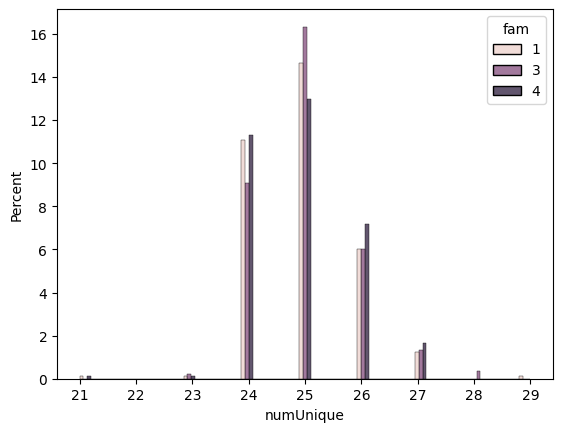

In [143]:
DF = pd.read_csv('data/Mar2023/combined_filtered.csv')
DF = DF[~DF.fSumGt7]

print('Number of participants in each group:')
counts = DF.groupby(['pid', 'condition']).head(1).groupby('condition')[['count']].count().reset_index()
print(counts)

d = dict(
    pid = [],
    stage = [],
    fam = [],
    numUnique = []
)
for (pid, stage, fam), f in DF.query('stage == "test1"').groupby(['pid', 'stage', 'famInd'])[['features']]:
    c = Counter(f.values.squeeze())
    nunique = len(c)
    d['pid'].append(pid)
    d['stage'].append(stage)
    d['fam'].append(fam)
    d['numUnique'].append(nunique)

df = pd.DataFrame(d)

bins = list(range(15, 30, 1))
histplot(data=df, x='numUnique', hue='fam',  stat='percent', multiple='dodge')